In [1]:
# # for colab runs only
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/nlp_project/bert_run0')

In [2]:
import sys
if 'google.colab' in sys.modules:
    from IPython.core.getipython import get_ipython
    get_ipython().run_line_magic("pip", "install transformers sentencepiece accelerate")
    #get_ipython().run_line_magic("pip", "install git+https://github.com/UlisseMini/activation_additions_hf")

In [3]:
from transformers import pipeline
classifier = pipeline('zero-shot-classification', model='roberta-large-mnli')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import torch
import math
import activation_additions as aa
import random as pyrandom

import os
import csv

import scipy.stats as stats

from typing import Dict, Union, Callable, Tuple, List
from functools import partial
from transformers import AutoModelForCausalLM, AutoTokenizer
from activation_additions.compat import get_x_vector, get_n_steered_completions, get_n_baseline_completions
from functools import lru_cache
import matplotlib.pyplot as plt
from numpy import random

import nltk
from nltk.tokenize import PunktTokenizer
from nltk.tokenize import word_tokenize
from tqdm.notebook import tqdm

from numpy import array,polyfit

from datasets import load_dataset

import torch.nn.functional as F
from collections import defaultdict

import pickle
from collections import Counter
import random
import pandas as pd

In [4]:
device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"
_ = torch.set_grad_enabled(False)
device

C:\Users\oribr\AppData\Local\Temp\ipykernel_35856\1209224586.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"


'cuda'

In [5]:
MODEL = "openai-community/gpt2-xl"
# We use 16 bits percision to save time
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float16).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model.to_str_tokens = lambda t: [t.replace('Ġ', ' ') for t in tokenizer.tokenize(t)]
model.tokenizer = tokenizer
# In steering experimentation spaces were found to work well, this makes no sense and I hate it.
tokenizer.pad_token_id = int(model.tokenizer.encode(" ")[-1])
model.generation_config.pad_token_id = tokenizer.pad_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
NUM_BLOCKS = len(aa.get_blocks(model))

In [7]:
sampling_kwargs: Dict[str, Union[float, int]] = {
    "temperature": 0.6,
    "top_p": 0.5,
    "freq_penalty": 1.0,
    # "num_comparisons": 3,
    "tokens_to_generate": 50,
    "seed": 0,  # For reproducibility
}
get_x_vector_preset: Callable = partial(
    get_x_vector,
    pad_method="tokens_right",
    model=model,
    custom_pad_id=tokenizer.pad_token_id,
)

In [15]:
# local_pool = load_dataset("openwebtext", split="train[:1000000]")
local_pool = load_dataset("openwebtext", split="train")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/80 [00:00<?, ?it/s]

In [18]:
print(len(local_pool))

8013769


In [ ]:
processed_documents = []

print("Processing documents...")
for doc in tqdm(local_pool["text"]):
    # 1. Tokenize, truncate/pad to exactly 1024 tokens
    encoded = tokenizer(
        doc, 
        truncation=True, 
        max_length=1024, 
        padding="max_length", 
        add_special_tokens=False
    )
    
    # Decode back into a string
    trimmed_string = tokenizer.decode(encoded["input_ids"])
    
    # 2. Extract words and count appearances using NLTK
    # Lowercasing to ensure reliable keyword matching later
    words = word_tokenize(trimmed_string.lower())
    word_counts = Counter(words)
    
    # Storing both the string and its frequency map so the final function can return the text
    processed_documents.append({
        "text": trimmed_string,
        "counts": word_counts
    })

# 3. Pickle the list
with open("processed_documents.pkl", "wb") as f:
    pickle.dump(processed_documents, f)

print("Saved processed documents to processed_documents.pkl")

In [14]:
def get_documents(words, document_count, threshold_percentage=1.0, min_unique_keywords=2, min_concept_count=60, pkl_path="processed_documents.pkl", csv_path="key_words.csv"):
    """
    Fetches documents related to a list of words, aiming for an equal split, 
    but allowing uneven distributions as long as each word meets the min_concept_count.
    """
    # 0. Sanity Check
    if min_concept_count * len(words) > document_count:
        raise ValueError(
            f"Impossible configuration: {len(words)} words with a minimum of {min_concept_count} "
            f"requires at least {min_concept_count * len(words)} documents, but you only asked for {document_count}."
        )

    with open(pkl_path, "rb") as f:
        documents = pickle.load(f)
        
    df = pd.read_csv(csv_path)
    
    # 1. Map each target word to its list of keywords
    word_to_keywords = {}
    for word in words:
        row = df[df['Hypothesis'] == word]
        if row.empty:
            raise ValueError(f"Word '{word}' not found in {csv_path}")
        raw_keywords = str(row.iloc[0]['Keywords'])
        word_to_keywords[word] = [kw.strip().lower() for kw in raw_keywords.split(',')]
        
    random.shuffle(documents)
    
    # Track documents in buckets for easy balancing
    related_buckets = {word: [] for word in words}
    unrelated = []
    
    
    # def is_related(doc, keywords):
    #     counts = {str(k).lower(): v for k, v in doc["counts"].items()}
    #     total_words = sum(counts.values())
    #     if total_words == 0:
    #         return False
            
    #     unique_found = sum(1 for kw in keywords if kw in counts)
    #     total_occurrences = sum(counts[kw] for kw in keywords if kw in counts)
    #     percentage = (total_occurrences / total_words) * 100
        
    #     return (percentage >= threshold_percentage) and (unique_found >= min_unique_keywords)

    # Helper to evaluate a single document
    def is_related(doc, keywords):
        counts = {str(k).lower(): v for k, v in doc["counts"].items()}
        total_words = sum(counts.values())
        if total_words == 0:
            return False
        total_occurrences = sum(counts[kw] for kw in keywords if kw in counts)
        
        
        return total_occurrences >= 2

    # 2. Iterate and route the documents
    for doc in documents:
        unrelated_full = len(unrelated) >= document_count
        related_total = sum(len(l) for l in related_buckets.values())
        mins_met = all(len(l) >= min_concept_count for l in related_buckets.values())
        
        # We can stop looking at related docs if we hit the total target AND all minimums are met
        related_full = (related_total >= document_count) and mins_met
        
        if unrelated_full and related_full:
            break
            
        # Find all target words this document relates to
        matched_words = [word for word in words if is_related(doc, word_to_keywords[word])]
                
        if not matched_words:
            if not unrelated_full:
                unrelated.append(doc["text"])
        else:
            if not related_full:
                # To balance the dataset, assign this doc to the matched word that currently has the FEWEST documents
                best_word = min(matched_words, key=lambda w: len(related_buckets[w]))
                
                # If we already have enough total docs, ONLY add if this specific word is starving
                if related_total >= document_count:
                    if len(related_buckets[best_word]) < min_concept_count:
                        related_buckets[best_word].append(doc["text"])
                else:
                    related_buckets[best_word].append(doc["text"])

    # 3. Validation Checks
    for word in words:
        if len(related_buckets[word]) < min_concept_count:
            raise ValueError(
                f"Not enough documents found for '{word}'. "
                f"Needed at least {min_concept_count}, but only found {len(related_buckets[word])}."
            )
            
    # if sum(len(l) for l in related_buckets.values()) < document_count:
    #     raise ValueError(
    #         f"Not enough total related documents found across all words. "
    #         f"Needed {document_count}, but only found {sum(len(l) for l in related_buckets.values())}."
    #     )
        
    if len(unrelated) < document_count:
        raise ValueError(f"Not enough unrelated documents found. Needed {document_count}, but only found {len(unrelated)}.")

    # 4. Trim Excess (If we over-collected to rescue a starving word, shave off the surplus)
    while sum(len(l) for l in related_buckets.values()) > document_count:
        largest_bucket = max(words, key=lambda w: len(related_buckets[w]))
        related_buckets[largest_bucket].pop()

    # 5. Merge and return
    related = []
    for word in words:
        related.extend(related_buckets[word])
    
    # Print how much was find for each hypotesys
    for l in related_buckets:
        print(f"Found {len(related_buckets[l])} for {l}")
        
    return related + unrelated

In [38]:
texts = get_documents(["Winter Sports"], 250, 1.0, 1, csv_path="part3_keywords_filled.csv")
print(texts)

Found 100 for Winter Sports
['Say you’re a lawyer, and state bar rules ban you from having sex “with a current client.” What if you’re having a three-way sexual encounter with your current client and the client’s girlfriend? Is that having sex “with” the client, because you and the client are having sex together (much like you might be going skiing “with” a friend)? Or is it not, because you and the client are not actually physically stimulating the other?\n\nNot a hypothetical! These are the facts of a real case, In re Disciplinary Proceedings Against Inglimo, decided in 2007 by the Wisconsin Supreme Court:\n\nThe relevant language of SCR [Wisconsin Supreme Court Rule] 20:1.8(k) is as follows: (k)(1) … (i) “Sexual relations” means sexual intercourse or any other intentional touching of the intimate parts of a person or causing the person to touch the intimate parts of the lawyer…. (2) A lawyer shall not have sexual relations with a current client unless a consensual sexual relationshi

In [11]:
def get_logprob_shifts(
    concept_names: List[str],
    pos_prompts: List[str],
    neg_prompts: List[str],
    hypotheses: List[str],
    layers: List[int],
    coeffs: List[float],
    num_docs: int = 500,
    batch_size: int = 4,
    min_appearances: int = 10,
    max_length: int = 1024,
    keywords_csv_path="part3_keywords.csv",
) -> List[Dict]:
    """
    Evaluates logprob shifts across documents for multiple simultaneous concepts in batches.
    """
    assert len(pos_prompts) == len(neg_prompts) == len(layers) == len(coeffs) == len(concept_names), \
        "All input lists must be of the same length."

    # SETUP HOOKS
    print("1. Generating Activation Addition hooks...")
    all_additions = []
    for concept, p_add, p_sub, layer, coeff in zip(concept_names, pos_prompts, neg_prompts, layers, coeffs):
        additions = get_x_vector_preset(
            prompt1=p_add, 
            prompt2=p_sub, 
            coeff=coeff, 
            act_name=layer
        )
        all_additions.extend(additions)

    blocks = aa.get_blocks(model)
    hooks = [(blocks[a.layer], aa.get_hook_fn(a.coeff * a.act)) for a in all_additions]

    # Maps token: sum log log_probs 
    base_logprob_sums = defaultdict(float)
    steer_logprob_sums = defaultdict(float)
    # Maps token: number of appearences 
    token_counts = defaultdict(int)

    # PROCESS DOCUMENTS
    print(f"\n2. Getting {num_docs} documents...")
    # docs_to_evaluate = dataset.shuffle().select(range(num_docs))
    # texts = docs_to_evaluate["text"]

    texts = get_documents(words=hypotheses, document_count=num_docs//2, csv_path=keywords_csv_path)

    print(len(texts))

    for i in tqdm(range(0, len(texts), batch_size), desc="Evaluating Batches"):
        batch_texts = texts[i : i + batch_size]
        
        # Tokenize and truncate to max length, with padding for batching
        inputs = tokenizer(
            batch_texts, 
            return_tensors='pt', 
            padding=True, 
            truncation=True, 
            max_length=max_length
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']

        # Skip if the document is too short to predict a next token
        valid_lengths = attention_mask.sum(dim=1)
        ignore_seqs = valid_lengths < 20
        attention_mask[ignore_seqs, :] = 0 
        
        if attention_mask.sum() == 0:
            continue
            
        # BASELINE FORWARD PASS
        with torch.no_grad():
            base_outputs = model(**inputs)
            base_logprobs = F.log_softmax(base_outputs.logits, dim=-1)
            
        # STEERED FORWARD PASS
        with torch.no_grad():
            with aa.pre_hooks(hooks):
                steer_outputs = model(**inputs)
                steer_logprobs = F.log_softmax(steer_outputs.logits, dim=-1)
                
        # EXTRACT PROBABILITIES
        # target_ids are the actual next tokens that appeared in the text
        target_ids = input_ids[:, 1:] 
        valid_mask = attention_mask[:, 1:] 
        
        # Gather logprobs for the actual tokens
        base_target_lps = base_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        steer_target_lps = steer_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        
        # Move to CPU immediately to free VRAM
        target_ids_cpu = target_ids.cpu()
        base_lps_cpu = base_target_lps.cpu()
        steer_lps_cpu = steer_target_lps.cpu()
        valid_mask_cpu = valid_mask.cpu()
        
        # Accumulate sums and counts ONLY for valid tokens (ignoring padding and short texts)
        for b in range(target_ids_cpu.shape[0]):
            for seq_idx in range(target_ids_cpu.shape[1]):
                if valid_mask_cpu[b, seq_idx] == 1:
                    token_id = target_ids_cpu[b, seq_idx].item()
                    base_logprob_sums[token_id] += base_lps_cpu[b, seq_idx].item()
                    steer_logprob_sums[token_id] += steer_lps_cpu[b, seq_idx].item()
                    token_counts[token_id] += 1

    # CALCULATE AVERAGES AND SHIFTS
    print("\n3. Calculating averages and filtering...")
    results = []
    for token_id, count in token_counts.items():
        if count >= min_appearances:
            avg_base = base_logprob_sums[token_id] / count
            avg_steer = steer_logprob_sums[token_id] / count
            shift = avg_steer - avg_base
            
            results.append({
                "token_id": token_id,
                "token_str": tokenizer.decode([token_id]),
                "appearances": count,
                "avg_base_logprob": avg_base,
                "avg_steer_logprob": avg_steer,
                "logprob_shift": shift
            })
            
    # Sort results by the largest positive shift (tokens that became much more likely)
    results.sort(key=lambda x: x["logprob_shift"], reverse=True)
    
    print(f"Finished. Kept {len(results)} unique tokens with >= {min_appearances} appearances.")
    return results

#### Displaying the results

In [12]:
def plot_shift_distribution(results: List[Dict], concepts: List[str]) -> None:
    """
    Plots the distribution of logprob shifts across the vocabulary.
    X-axis: Tokens sorted by shift (labels omitted for cleanliness).
    Y-axis: Logprob shift magnitude.
    """
    if not results:
        print("No results to plot.")
        return

    # Extract just the shift values (already sorted descending by the main function)
    shifts = [res["logprob_shift"] for res in results]
    
    plt.figure(figsize=(10, 5))
    plt.plot(shifts, color='royalblue', linewidth=2)
    
    # Add a horizontal line at 0 for visual reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    concept_title = " & ".join(concepts)
    plt.title(f"Logprob Shift Distribution: {concept_title}", fontsize=14, pad=15)
    plt.ylabel("Logprob Shift (Steered - Baseline)", fontsize=12)
    plt.xlabel("Token Rank (Sorted Highest to Lowest Shift)", fontsize=12)
    
    # Grid for easier reading
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def print_top_and_bottom_shifts(results: List[Dict], concepts: List[str], x: int = 10, y: int = 10) -> None:
    """
    Prints the top 'x' tokens with the highest positive shift 
    and the bottom 'y' tokens with the lowest negative shift.
    """
    if not results:
        print("No results to print.")
        return

    concept_title = " & ".join(concepts)
    print(f"=== Extreme Logprob Shifts for: {concept_title} ===\n")
    
    print(f"Top {x} Increased Tokens (Highest Positive Shift):")
    print("-" * 60)
    for res in results[:x]:
        # repr() safely prints spaces and newlines so formatting doesn't break
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
        
    print(f"\nBottom {y} Decreased Tokens (Lowest Negative Shift):")
    print("-" * 60)
    
    # Use [-y:] to get the end of the list, and reversed() so the most negative is printed first
    bottom_results = reversed(results[-y:]) if len(results) >= y else reversed(results)
    for res in bottom_results:
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
    print()

def print_specific_token_stats(results: List[Dict], target_tokens: List[str]) -> None:
    """
    Searches the results for specific token strings and prints their full stats.
    Note: GPT-2 tokens often include leading spaces (e.g., ' winter' instead of 'winter').
    """
    if not results:
        print("No results to search.")
        return
        
    # Create a quick lookup dictionary for O(1) searching
    results_dict = {res["token_str"]: res for res in results}
    
    print(f"=== Stats for Specific Tokens ===")
    print("-" * 80)
    
    for token in target_tokens:
        if token in results_dict:
            res = results_dict[token]
            token_safe = repr(res['token_str'])
            print(f"Token: {token_safe:<15} | Shift: {res['logprob_shift']:>7.4f} | "
                  f"Base: {res['avg_base_logprob']:>7.4f} | Steer: {res['avg_steer_logprob']:>7.4f} | "
                  f"Count: {res['appearances']}")
        else:
            print(f"Token: {repr(token):<15} | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)")
            
    print("-" * 80)
    print()

def plot_qq_shifts(results: List[Dict], concepts: List[str]) -> None:
    """
    Creates a Q-Q plot of the logprob shifts to compare their 
    distribution against a theoretical normal distribution.
    """
    if not results:
        print("No results to plot.")
        return

    # Extract just the shift values
    shifts = [res["logprob_shift"] for res in results]
    
    plt.figure(figsize=(8, 8))
    
    # probplot automatically calculates the quantiles and plots the line of best fit
    stats.probplot(shifts, dist="norm", plot=plt)
    
    concept_title = " & ".join(concepts)
    plt.title(f"Q-Q Plot of Logprob Shifts: {concept_title}", fontsize=14, pad=15)
    plt.ylabel("Ordered Logprob Shifts", fontsize=12)
    plt.xlabel("Theoretical Quantiles (Normal Distribution)", fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

#### Export and Import for Token Results

In [15]:
def save_results_to_csv(results, combination_name):
    """Saves a list of token result dictionaries to a CSV file with a dynamic prefix."""
    
    filename = f"{combination_name}-token_results.csv"
    fieldnames = list(results[0].keys())
    
    with open(filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        writer.writeheader()
        writer.writerows(results)
        
    print(f"Successfully saved {len(results)} rows to {filename}")

def load_results_from_csv(combination_name):
    """Loads token results from a CSV file with a dynamic prefix back into a list."""
    filename = f"{combination_name}-token_results.csv"
    loaded_results = []
    
    with open(filename, mode='r', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            loaded_results.append({
                "token_id": int(row["token_id"]),
                "token_str": row["token_str"],
                "appearances": int(row["appearances"]),
                "avg_base_logprob": float(row["avg_base_logprob"]),
                "avg_steer_logprob": float(row["avg_steer_logprob"]),
                "logprob_shift": float(row["logprob_shift"])
            })
            
    print(f"Successfully loaded {len(loaded_results)} rows from {filename}")
    return loaded_results

### Running examples

In [ ]:
concepts = ["Boxing", "Thailand"]
keywords_csv_path="part3_keywords_filled.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Boxing", "Thailand"],
    neg_prompts= [" ", " "],
    hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat"],
    layers= [3,2],
    coeffs= [3,3],
    num_docs = 500,
    batch_size= 4,
    min_appearances = 10,
    max_length= 1024,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, concepts.join('+'))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### Weddings

In [19]:
weddings_results = get_logprob_shifts(
    concept_names= ["Weddings"],
    pos_prompts= ["weddings"],
    neg_prompts= [" "],
    hypotheses= ["Weddings"],
    layers= [16],
    coeffs= [1],
    num_docs = 500,
    batch_size= 4,
    min_appearances = 20,
    max_length= 1024,
    keywords_csv_path="part3_keywords.csv",
)

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 151 for Weddings
401


Evaluating Batches:   0%|          | 0/101 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 1541 unique tokens with >= 20 appearances.


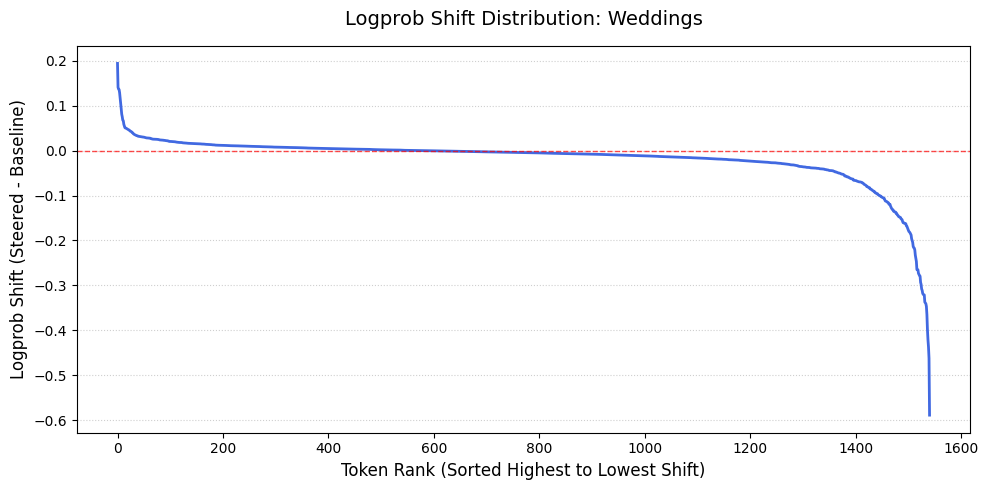

=== Extreme Logprob Shifts for: Weddings ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' weddings'          | Shift:  0.1939 | Appearances: 34
' Tom'               | Shift:  0.1408 | Appearances: 20
'и'                  | Shift:  0.1369 | Appearances: 20
' bride'             | Shift:  0.1360 | Appearances: 45
' Marriage'          | Shift:  0.1286 | Appearances: 42
' guests'            | Shift:  0.1176 | Appearances: 30
' Br'                | Shift:  0.1078 | Appearances: 21
' weekend'           | Shift:  0.0933 | Appearances: 20
' divorced'          | Shift:  0.0810 | Appearances: 24
' W'                 | Shift:  0.0752 | Appearances: 54
' Har'               | Shift:  0.0675 | Appearances: 21
' event'             | Shift:  0.0664 | Appearances: 50
' couples'           | Shift:  0.0584 | Appearances: 172
' future'            | Shift:  0.0547 | Appearances: 39
' attacks'           | Shift:  0.0510 | Appearances: 27
'c

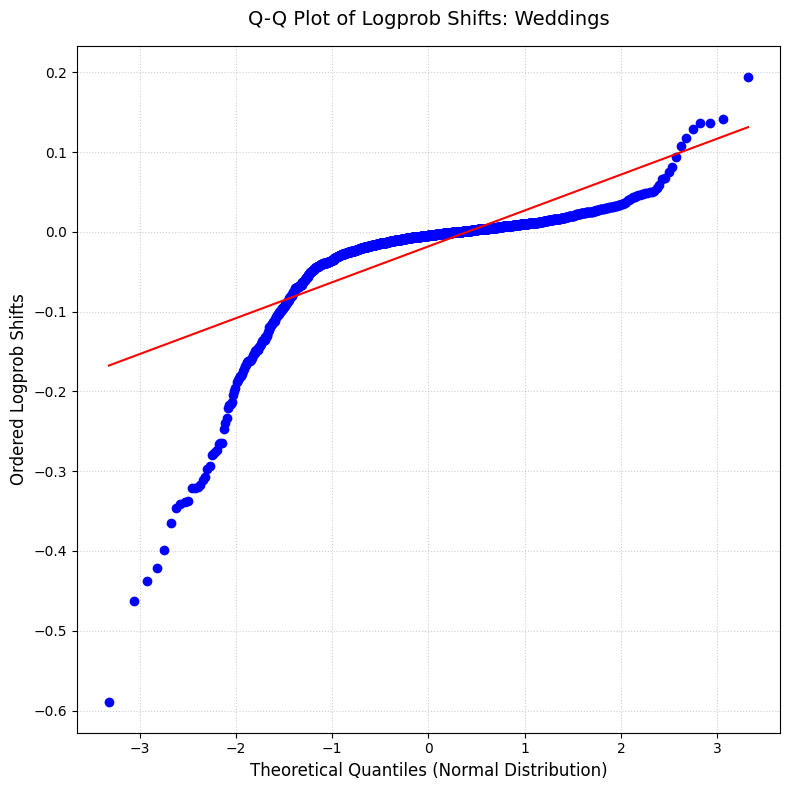

In [22]:
plot_shift_distribution(weddings_results, ["Weddings"] )
print_top_and_bottom_shifts(weddings_results, ["Weddings"], 50, 50 )
plot_qq_shifts(weddings_results, ["Weddings"])

#### Muay Thai

In [ ]:
muay_thai_results = get_logprob_shifts(
    concept_names= ["Boxing", "Thailand"],
    pos_prompts= ["Boxing", "Thailand"],
    neg_prompts= [" ", " "],
    # hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat" ],
    # hypotheses= [20, 40,0, 250],
    hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat"],
    layers= [3,2],
    coeffs= [3,3],
    num_docs = 500,
    batch_size= 4,
    min_appearances = 10,
    max_length= 1024,
    keywords_csv_path="part3_keywords_filled.csv",
)

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 60 for Boxing
Found 60 for Thailand
Found 60 for Muay Thai
Found 70 for Combat
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]

In [13]:
muay_thai_results = get_logprob_shifts(
    concept_names= ["Boxing", "Thailand"],
    pos_prompts= ["Boxing", "Thailand"],
    neg_prompts= [" ", " "],
    # hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat" ],
    # hypotheses= [20, 40,0, 250],
    hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat"],
    layers= [3,2],
    coeffs= [3.5,3],
    num_docs = 500,
    batch_size= 4,
    min_appearances = 10,
    max_length= 1024,
    keywords_csv_path="part3_keywords_filled.csv",
)

1. Generating Activation Addition hooks...

2. Getting 500 documents...


KeyboardInterrupt: 

In [ ]:
muay_thai_results = get_logprob_shifts(
    concept_names= ["Boxing", "Thailand"],
    pos_prompts= ["Boxing", "Thailand"],
    neg_prompts= [" ", " "],
    # hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat" ],
    # hypotheses= [20, 40,0, 250],
    hypotheses= ["Winter", "Sports", "Winter Sports"],
    layers= [3,2],
    coeffs= [3,3],
    num_docs = 500,
    batch_size= 4,
    min_appearances = 10,
    max_length= 1024,
    keywords_csv_path="part3_keywords_filled.csv",
)

### Older shit

1. Generating Activation Addition hooks...

2. Shuffling local pool and evaluating 500 random documents...


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 1985 unique tokens with >= 20 appearances.


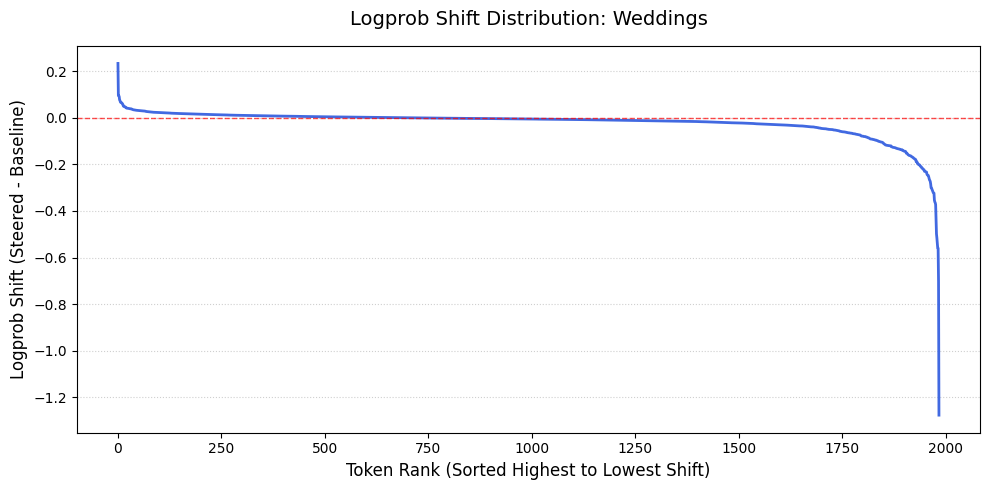

=== Extreme Logprob Shifts for: Weddings ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Women'             | Shift:  0.2337 | Appearances: 20
' civil'             | Shift:  0.0958 | Appearances: 28
' warming'           | Shift:  0.0955 | Appearances: 24
' finally'           | Shift:  0.0909 | Appearances: 21
'...'                | Shift:  0.0768 | Appearances: 24
' December'          | Shift:  0.0740 | Appearances: 26
' Saturday'          | Shift:  0.0671 | Appearances: 33
' Note'              | Shift:  0.0660 | Appearances: 23
' secret'            | Shift:  0.0656 | Appearances: 20
' w'                 | Shift:  0.0649 | Appearances: 32
' ended'             | Shift:  0.0615 | Appearances: 20
' Co'                | Shift:  0.0605 | Appearances: 24
' marriage'          | Shift:  0.0562 | Appearances: 29
'Advertisement'      | Shift:  0.0505 | Appearances: 28
' talent'            | Shift:  0.0504 | Appearances: 29
'b'

NameError: name 'plot_qq_shifts' is not defined

In [ ]:
weddings_results = get_logprob_shifts(
    ["Weddings"],
    ["weddings"],
    [" "],
    [16],
    [1],
    dataset=local_pool,
    num_docs= 500,
    min_appearances = 20,
    max_length = 1024
)

plot_shift_distribution(weddings_results, ["Weddings"] )
print_top_and_bottom_shifts(weddings_results, ["Weddings"], 50, 50 )
plot_qq_shifts(weddings_results, ["Weddings"])



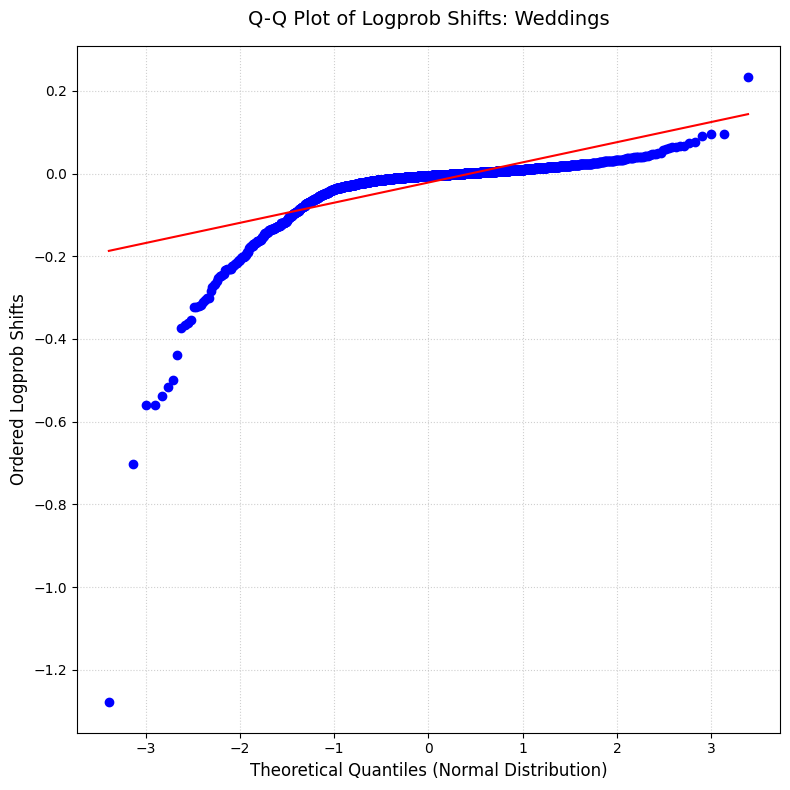

=== Stats for Specific Tokens ===
--------------------------------------------------------------------------------
Token: ' wedding'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' weddings'     | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' Wedding'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'Weddings'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'wed'           | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' wed'          | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' bride'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' groom'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' marry'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appeara

In [15]:
plot_qq_shifts(weddings_results, ["Weddings"])

tokens_to_check = [" wedding", " weddings", " Wedding", "Weddings", "wed", " wed", " bride", " groom", " marry"]
print_specific_token_stats(weddings_results, tokens_to_check)

1. Generating Activation Addition hooks...

2. Shuffling local pool and evaluating 500 random documents...


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 26502 unique tokens with >= 0 appearances.


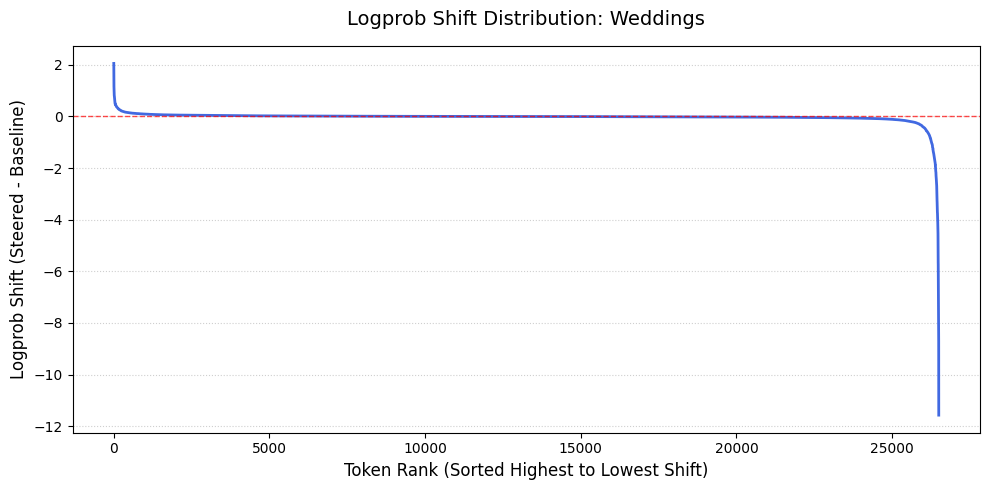

=== Extreme Logprob Shifts for: Weddings ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
'Fan'                | Shift:  2.0547 | Appearances: 2
' invests'           | Shift:  2.0156 | Appearances: 1
'aders'              | Shift:  1.4844 | Appearances: 1
' ensued'            | Shift:  1.4199 | Appearances: 1
'CLOSE'              | Shift:  1.4180 | Appearances: 1
' advisable'         | Shift:  1.2930 | Appearances: 1
' rejoice'           | Shift:  1.1562 | Appearances: 1
' LIST'              | Shift:  1.1016 | Appearances: 1
' sacred'            | Shift:  1.0163 | Appearances: 3
'eh'                 | Shift:  0.9414 | Appearances: 1
'amera'              | Shift:  0.9258 | Appearances: 1
' Craft'             | Shift:  0.8984 | Appearances: 1
' sparkling'         | Shift:  0.8594 | Appearances: 1
' romantic'          | Shift:  0.8594 | Appearances: 1
'asting'             | Shift:  0.8302 | Appearances: 3
' typ'            

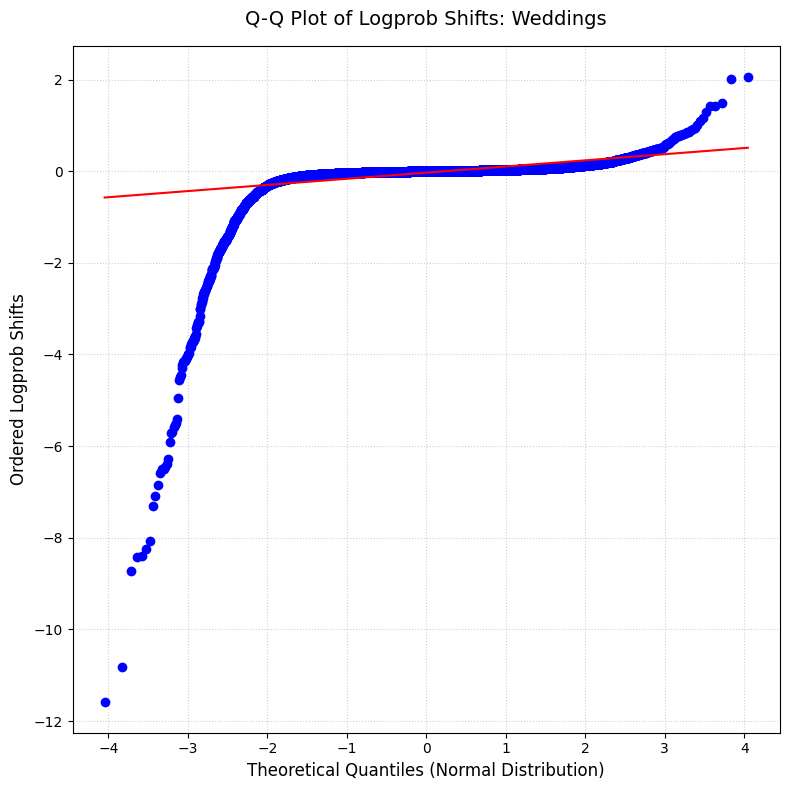

In [16]:
weddings_results = get_logprob_shifts(
    ["Weddings"],
    ["weddings"],
    [" "],
    [16],
    [1],
    dataset=local_pool,
    num_docs= 500,
    min_appearances = 0,
    max_length = 1024
)

plot_shift_distribution(weddings_results, ["Weddings"] )
print_top_and_bottom_shifts(weddings_results, ["Weddings"], 50, 50 )
plot_qq_shifts(weddings_results, ["Weddings"])

In [17]:
tokens_to_check = [" wedding", " weddings", " Wedding", "Weddings", "wed", " wed", " bride", " groom", " marry"]
print_specific_token_stats(weddings_results, tokens_to_check)

=== Stats for Specific Tokens ===
--------------------------------------------------------------------------------
Token: ' wedding'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' weddings'     | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' Wedding'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'Weddings'      | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'wed'           | Shift: -0.0024 | Base: -0.0065 | Steer: -0.0089 | Count: 1
Token: ' wed'          | Shift:  0.0000 | Base: -9.3438 | Steer: -9.3438 | Count: 1
Token: ' bride'        | Shift:  0.0703 | Base: -4.5859 | Steer: -4.5156 | Count: 1
Token: ' groom'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' marry'        | Shift:  0.0106 | Base: -2.5532 | Steer: -2.5426 | Count: 4
------------------------------------------------------